# Loan Risk Assessment Platform

## Exploratory Data Analysis (EDA)

### Objective
The objective of this notebook is to explore the loan prediction dataset, understand its structure, identify data quality issues, analyze feature distributions, and generate business insights that will guide feature engineering and model development.

In [1]:
# Standard Library
import warnings

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
warnings.filterwarnings("ignore")

# Visualization settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("../data/raw/train.csv")

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Dataset Overview

In [5]:
df.shape

(614, 13)

In [6]:
# column 
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [7]:
# Data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [8]:
#first five rows
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [9]:
# Random sample
df.sample(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
450,LP002446,Male,Yes,2,Not Graduate,No,2309,1255.0,125.0,360.0,0.0,Rural,N
356,LP002149,Male,Yes,2,Graduate,No,8333,3167.0,165.0,360.0,1.0,Rural,Y
174,LP001603,Male,Yes,0,Not Graduate,Yes,4344,736.0,87.0,360.0,1.0,Semiurban,N
460,LP002478,NaN,Yes,0,Graduate,Yes,2083,4083.0,160.0,360.0,NaN,Semiurban,Y
244,LP001811,Male,Yes,0,Not Graduate,No,3406,4417.0,123.0,360.0,1.0,Semiurban,Y


In [10]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [4]:
df.describe(include="object")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


# 2. Missing Value Analysis

In [5]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values = missing_values[missing_values["Missing Values"] > 0]
missing_values.sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage
Credit_History,50,8.143322
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Dependents,15,2.442997
Loan_Amount_Term,14,2.280130
Gender,13,2.117264
Married,3,0.488599


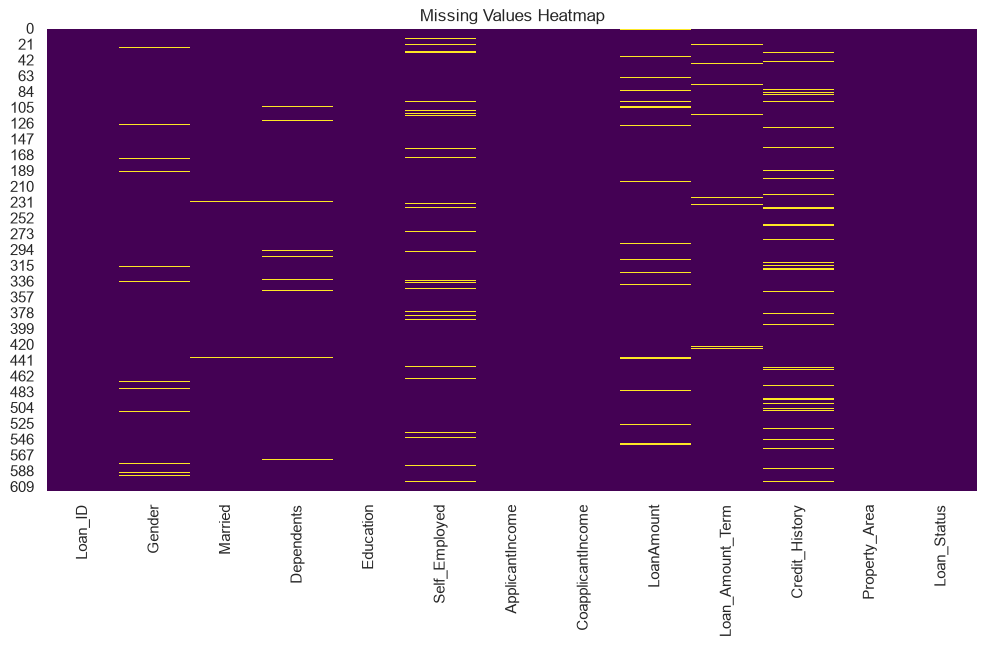

In [6]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")
plt.show()

Observations

The dataset contains missing values in several columns.
Credit_History has the highest number of missing values (50).
Self_Employed and LoanAmount also contain notable missing values.
Most missing values appear scattered throughout the dataset rather than concentrated in specific rows.
These missing values will need appropriate imputation before model training.

# 3. Duplicate Records

In this section, we check whether the dataset contains duplicate rows. Duplicate records can introduce bias into the analysis and model training, so they should be identified and handled appropriately.

In [3]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [4]:
df["Loan_ID"].duplicated().sum()

np.int64(0)

### Observations

- No duplicate rows were found in the dataset.
- Each loan application appears to represent a unique record.
- No duplicate removal is required at this stage.

#Target Variable Analysis
So before training any classifier, we always ask: Is the target variable balanced or imbalanced?

In [5]:
df["Loan_Status"].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [6]:
df["Loan_Status"].value_counts(normalize=True) * 100

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64

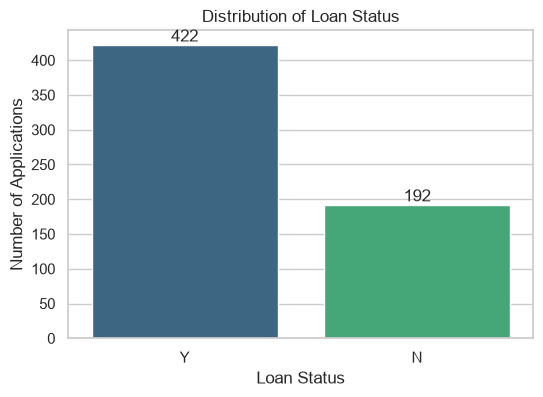

In [8]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data = df,
    x="Loan_Status",
    palette="viridis"
)


for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.show()

### Observations

- The dataset contains **422 approved loans (Y)** and **192 rejected loans (N)**.
- Approximately **68.7%** of the applications are approved, while **31.3%** are rejected.
- The target variable is **slightly imbalanced**, with approved loans being the majority class.
- Although the imbalance is not severe, it should be considered during model evaluation.

### Business Interpretation

The historical data indicates that the bank has approved a larger proportion of loan applications than it has rejected. This suggests that loan approvals are more common in the dataset.

Since the classes are moderately imbalanced, relying solely on accuracy could overestimate model performance. Therefore, additional evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC will be used to ensure the model performs well for both approved and rejected loan applications.

Univariate analysis (analysis of 1 type of feature)
we'll divide the features into two groups: Numerical Features, Categorical Features

In [9]:
# Numerical features
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical features
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Categorical Features:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


# 5.1 Applicant Income Analysis

### Objective

Analyze the distribution of applicants' income to understand its spread, identify outliers, and detect any skewness that may influence feature engineering and model performance.

In [10]:
df["ApplicantIncome"].describe()

count      614.000000
mean      5403.459283
std       6109.041673
min        150.000000
25%       2877.500000
50%       3812.500000
75%       5795.000000
max      81000.000000
Name: ApplicantIncome, dtype: float64

In [11]:
print(f"Median : {df['ApplicantIncome'].median():.2f}")
print(f"Skewness : {df['ApplicantIncome'].skew():.2f}")
print(f"Kurtosis : {df['ApplicantIncome'].kurt():.2f}")

Median : 3812.50
Skewness : 6.54
Kurtosis : 60.54


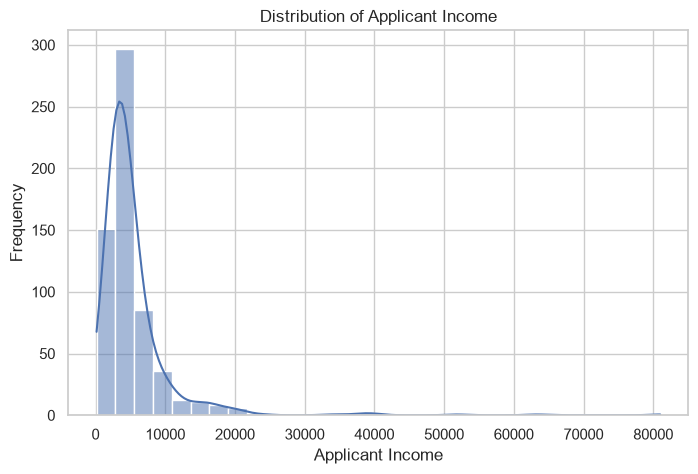

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="ApplicantIncome",
    bins=30,
    kde=True
)

plt.title("Distribution of Applicant Income")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")

plt.show()


| Skewness | Interpretation          |
| -------: | ----------------------- |
|      ≈ 0 | Symmetric               |
| 0.5 to 1 | Moderately right-skewed |
|      > 1 | Highly right-skewed     |


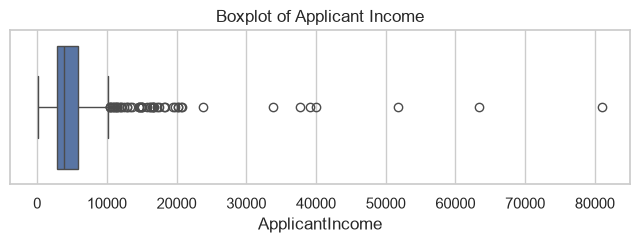

In [13]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df["ApplicantIncome"]
)

plt.title("Boxplot of Applicant Income")

plt.show()

### Observations

- The average applicant income (₹5,403) is considerably higher than the median income (₹3,812), indicating a positively skewed distribution.
- The histogram shows that most applicants fall within the lower income range, while a small number of applicants have exceptionally high incomes.
- The boxplot reveals several extreme outliers in applicant income.
- A skewness value of **6.54** confirms that the distribution is highly right-skewed.
- The high kurtosis value (**60.54**) indicates heavy tails and the presence of numerous extreme observations.

### Business Interpretation

The majority of loan applicants belong to the low-to-middle income group, while a small proportion of high-income applicants creates a long upper tail in the distribution. These applicants may represent a distinct customer segment and should not be treated as erroneous records without further investigation. Since the income distribution is highly skewed, statistical measures such as the median provide a better representation of a typical applicant than the mean.